# 🔬 SignalMod — Notebook de Auditoría y Validación de Modelos
### `09_model_audit.ipynb` · Verificación independiente con pruebas reales

---

**Objetivo:** Demostrar con números reproducibles que el modelo DistilBERT fine-tuneado  
funciona correctamente — y compararlo contra todos los demás modelos del proyecto.

**Estructura:**
1. Setup y carga de modelos
2. Pruebas con frases propias (casos controlados)
3. Evaluación sobre el test set oficial (métricas reproducibles)
4. Comparativa entre todos los modelos del equipo
5. Análisis de errores (FP y FN)
6. Test en vivo con URL de YouTube (YouTube Data API)
7. Resumen ejecutivo con tabla final

> ⚠️ **Para ejecutar la sección 6** necesitas una API Key de YouTube Data API v3 (gratuita, 10.000 cuotas/día).  
> Las secciones 1–5 funcionan **sin ninguna API key**.


## 0. Instalación de dependencias

In [1]:
# Ejecuta esta celda una sola vez si falta alguna librería
# !pip install transformers torch scikit-learn pandas numpy matplotlib seaborn
# !pip install google-api-python-client  # solo para la sección 6 (YouTube API)
print("✅ Dependencias listas")


✅ Dependencias listas


## 1. Setup: Imports y configuración

In [26]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

# ─── Sklearn ───────────────────────────────
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score
)
from sklearn.model_selection import train_test_split

# ─── Joblib ────────────────────────────────
import joblib

# ─── HuggingFace ───────────────────────────
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# ─── Estilo plots ──────────────────────────
plt.style.use("dark_background")
COLORS = {"toxic": "#ff4444", "safe": "#00e676", "neutral": "#448aff", "warn": "#ffd740"}
RANDOM_STATE = 42

print(f"🐍 Python  : {sys.version.split()[0]}")
print(f"🔥 PyTorch : {torch.__version__}")
print(f"🤗 Transformers disponible: ✅")
print(f"🎲 Random state : {RANDOM_STATE}")
print(f"💻 Device  : {'CUDA' if torch.cuda.is_available() else 'CPU'}")


🐍 Python  : 3.10.20
🔥 PyTorch : 2.12.0+cu132
🤗 Transformers disponible: ✅
🎲 Random state : 42
💻 Device  : CUDA


In [27]:
# ─── Rutas del proyecto ─────────────────────────────────────────────────────
# Ajusta estas rutas según tu estructura de carpetas

PROJECT_ROOT = Path("..").resolve()          # raíz del proyecto
DATA_PATH    = PROJECT_ROOT / "data" / "raw" / "youtoxic_english_1000.csv"
LR_MODEL     = PROJECT_ROOT / "models" / "final_model.joblib"
HF_MODEL_DIR = PROJECT_ROOT / "models" / "finetuned_hf"

REPORT_DIR = PROJECT_ROOT / "reports" / "v2" / "audit"

# Si estás en la raíz del proyecto:
# DATA_PATH = Path("data/raw/youtoxic_english_1000.csv")

print("📂 Rutas configuradas:")
print(f"  CSV     : {DATA_PATH}  → {'✅' if DATA_PATH.exists() else '❌ NO ENCONTRADO'}")
print(f"  LR      : {LR_MODEL}  → {'✅' if LR_MODEL.exists() else '❌ NO ENCONTRADO'}")
print(f"  HF dir  : {HF_MODEL_DIR} → {'✅' if HF_MODEL_DIR.exists() else '❌ NO ENCONTRADO'}")


📂 Rutas configuradas:
  CSV     : /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/data/raw/youtoxic_english_1000.csv  → ✅
  LR      : /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/final_model.joblib  → ✅
  HF dir  : /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/finetuned_hf → ✅


## 2. Datos: reproducción del split oficial

In [4]:
# ─── Carga del dataset ──────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"📊 Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"   Tóxicos  : {df['IsToxic'].sum()} ({df['IsToxic'].mean():.1%})")
print(f"   No tóxicos: {(~df['IsToxic']).sum()} ({(~df['IsToxic']).mean():.1%})")

# ─── MISMO split que el pipeline del proyecto (random_state=42, test_size=0.2) ──
X_train, X_test, y_train, y_test = train_test_split(
    df["Text"], df["IsToxic"].astype(int),
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["IsToxic"]
)

print(f"\n🔪 Split oficial reproducido:")
print(f"   Train : {len(X_train)} muestras  ({y_train.sum()} tóxicas)")
print(f"   Test  : {len(X_test)}  muestras  ({y_test.sum()} tóxicas)")
print(f"\n📌 Primeros 3 comentarios del test set:")
for i, (txt, lbl) in enumerate(zip(X_test.head(3), y_test.head(3))):
    label_str = "🔴 TÓXICO" if lbl else "🟢 SEGURO"
    print(f"  [{label_str}] {txt[:100]}...")


📊 Dataset: 1000 filas x 15 columnas
   Tóxicos  : 462 (46.2%)
   No tóxicos: 538 (53.8%)

🔪 Split oficial reproducido:
   Train : 800 muestras  (370 tóxicas)
   Test  : 200  muestras  (92 tóxicas)

📌 Primeros 3 comentarios del test set:
  [🔴 TÓXICO] You should be legally allowed to run them down with no consequences...
  [🟢 SEGURO] So proud of a woman & mother that stands on principle, morality & just plain common sense! And not a...
  [🔴 TÓXICO] Non lethal weapon's do not control crowds lol. I love Rogan but this discussion was stupid as fuck....


## 3. Carga de modelos

In [5]:
models_loaded = {}

# ─── 3.1 Logistic Regression (sklearn pipeline) ─────────────────────────────
print("⏳ Cargando LR tuned (Optuna)...")
try:
    lr_pipeline = joblib.load(LR_MODEL)
    models_loaded["LR_tuned"] = lr_pipeline
    print("✅ LR tuned cargado")
except Exception as e:
    print(f"❌ LR: {e}")

# ─── 3.2 DistilBERT base fine-tuned (modelo propio del proyecto) ─────────────
print("\n⏳ Cargando DistilBERT fine-tuned (puede tardar 30-60s)...")
try:
    t0 = time.time()
    tokenizer_ft = AutoTokenizer.from_pretrained(str(HF_MODEL_DIR))
    model_ft = AutoModelForSequenceClassification.from_pretrained(str(HF_MODEL_DIR))
    model_ft.eval()
    distilbert_ft = pipeline(
        "text-classification",
        model=model_ft,
        tokenizer=tokenizer_ft,
        device=0 if torch.cuda.is_available() else -1,
        truncation=True,
        max_length=512
    )
    models_loaded["DistilBERT_finetuned"] = distilbert_ft
    print(f"✅ DistilBERT fine-tuned cargado en {time.time()-t0:.1f}s")
except Exception as e:
    print(f"❌ DistilBERT FT: {e}")

# ─── 3.3 Modelos HuggingFace Hub (zero-shot / sin fine-tuning) ───────────────
HF_MODELS = {
    "DistilBERT_toxic_zeroshot": "martin-ha/toxic-comment-model",
    "RoBERTa_hate_zeroshot"    : "cardiffnlp/twitter-roberta-base-hate",
}

for name, model_id in HF_MODELS.items():
    print(f"\n⏳ Cargando {name} desde HuggingFace Hub...")
    try:
        t0 = time.time()
        clf = pipeline(
            "text-classification",
            model=model_id,
            truncation=True,
            max_length=512,
            device=0 if torch.cuda.is_available() else -1,
        )
        models_loaded[name] = clf
        print(f"✅ {name} cargado en {time.time()-t0:.1f}s")
    except Exception as e:
        print(f"⚠️  {name}: {e} — se omite")

print(f"\n📦 Modelos disponibles: {list(models_loaded.keys())}")


⏳ Cargando LR tuned (Optuna)...
✅ LR tuned cargado

⏳ Cargando DistilBERT fine-tuned (puede tardar 30-60s)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 658.06it/s]


✅ DistilBERT fine-tuned cargado en 4.3s

⏳ Cargando DistilBERT_toxic_zeroshot desde HuggingFace Hub...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1790.83it/s]


✅ DistilBERT_toxic_zeroshot cargado en 1.7s

⏳ Cargando RoBERTa_hate_zeroshot desde HuggingFace Hub...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6531.16it/s]


✅ RoBERTa_hate_zeroshot cargado en 2.2s

📦 Modelos disponibles: ['LR_tuned', 'DistilBERT_finetuned', 'DistilBERT_toxic_zeroshot', 'RoBERTa_hate_zeroshot']


## 4. Funciones de predicción unificadas

In [6]:
def predict_lr(texts, model):
    """Predict with sklearn pipeline. Returns (labels, probas)."""
    if isinstance(texts, str):
        texts = [texts]
    preds = model.predict(texts)
    probas = model.predict_proba(texts)[:, 1]
    return preds, probas


def predict_hf(texts, clf, label_map=None, threshold=0.5):
    """
    Predict with HuggingFace pipeline.
    label_map: dict mapping model label strings to {0,1}
    Returns (labels, probas)
    """
    if isinstance(texts, str):
        texts = [texts]
    
    results = clf(texts, batch_size=16, truncation=True)
    
    # Detect positive label automatically if no map provided
    if label_map is None:
        sample_labels = {r["label"] for r in results}
        # Heuristic: label with highest score for a known toxic text
        toxic_test = clf(["you are a stupid idiot and i hate you"], truncation=True)[0]
        pos_label = toxic_test["label"]
        label_map = {pos_label: 1}
        neg_labels = sample_labels - {pos_label}
        for l in neg_labels:
            label_map[l] = 0
    
    probas, preds = [], []
    for r in results:
        mapped = label_map.get(r["label"], 0)
        score = r["score"] if mapped == 1 else 1 - r["score"]
        probas.append(score)
        preds.append(1 if score >= threshold else 0)
    
    return np.array(preds), np.array(probas)


def compute_metrics(y_true, y_pred, y_proba=None, model_name="Model"):
    """Compute full metrics dict."""
    metrics = {
        "model"    : model_name,
        "accuracy" : accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_toxic" : f1_score(y_true, y_pred, pos_label=1, average="binary"),
        "precision": classification_report(y_true, y_pred, output_dict=True)["1"]["precision"],
        "recall"   : classification_report(y_true, y_pred, output_dict=True)["1"]["recall"],
        "FP"       : int(((y_pred == 1) & (y_true == 0)).sum()),
        "FN"       : int(((y_pred == 0) & (y_true == 1)).sum()),
        "TP"       : int(((y_pred == 1) & (y_true == 1)).sum()),
        "TN"       : int(((y_pred == 0) & (y_true == 0)).sum()),
    }
    if y_proba is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
        except:
            metrics["roc_auc"] = None
    return metrics

print("✅ Funciones de predicción definidas")
print("   → predict_lr(texts, model)")
print("   → predict_hf(texts, clf, label_map, threshold)")
print("   → compute_metrics(y_true, y_pred, y_proba)")


✅ Funciones de predicción definidas
   → predict_lr(texts, model)
   → predict_hf(texts, clf, label_map, threshold)
   → compute_metrics(y_true, y_pred, y_proba)


## 5. Pruebas con frases propias (casos controlados)

Esta sección es la más importante para demostrar que el modelo funciona.  
Probamos casos con **respuesta conocida** para verificar que la predicción es correcta.


In [ ]:
# ─── Define tus frases aquí ──────────────────────────────────────────────────
# Añade las que quieras. Etiqueta manualmente si es TÓXICO (1) o SEGURO (0).

MANUAL_TESTS = [
    # (texto, etiqueta_real, descripción)
    
    # ── CASOS CLARAMENTE TÓXICOS ──
    ("I hate all these stupid people, they should die",         1, "Amenaza directa"),
    ("Black people are all criminals and should be locked up",  1, "Racismo explícito"),
    ("You are a disgusting piece of trash, go kill yourself",   1, "Insulto + incitación"),
    ("These immigrants are ruining our country, send them back",1, "Discurso de odio nacionalista"),
    ("Stupid cop brutality apologists, you're all disgusting",  1, "Insulto + provocación"),
    ("F*** the police and everyone who supports them",          1, "Lenguaje obsceno + odio"),

    # ── CASOS AMBIGUOS / DIFÍCILES ──
    ("The police in this video acted completely wrong",         0, "Crítica sin odio"),
    ("Black lives matter and we need systemic change now",      0, "Activismo sin odio"),
    ("This is absolutely outrageous and needs to stop",         0, "Indignación legítima"),
    ("I can't believe what I just watched, this is disgusting", 0, "Reacción emocional OK"),
    ("White privilege is real and must be acknowledged",        0, "Opinión política sin odio"),
    
    # ── CASOS CLARAMENTE SEGUROS ──
    ("Thank you for sharing this important video",              0, "Agradecimiento neutro"),
    ("I think we need more dialogue between communities",       0, "Constructivo"),
    ("The statistics clearly show systemic issues in policing", 0, "Análisis objetivo"),
    ("Can someone explain what happened in this situation?",    0, "Pregunta neutra"),
    
    # ── AÑADE LAS MÁS AQUÍ ──
    # ("tu frase aquí", 1 o 0, "descripción"),
]

print(f"📋 Total de frases de prueba: {len(MANUAL_TESTS)}")
print(f"   Tóxicas  (esperado=1): {sum(1 for _,l,_ in MANUAL_TESTS if l==1)}")
print(f"   Seguras  (esperado=0): {sum(1 for _,l,_ in MANUAL_TESTS if l==0)}")


📋 Total de frases de prueba: 15
   Tóxicas  (esperado=1): 6
   Seguras  (esperado=0): 9


In [8]:
# ─── Predicción sobre frases manuales ───────────────────────────────────────
texts_manual  = [t for t,_,_ in MANUAL_TESTS]
labels_manual = np.array([l for _,l,_ in MANUAL_TESTS])
descs_manual  = [d for _,_,d in MANUAL_TESTS]

results_manual = {}

for model_name, model_obj in models_loaded.items():
    print(f"⏳ Evaluando {model_name}...")
    try:
        if model_name == "LR_tuned":
            preds, probas = predict_lr(texts_manual, model_obj)
        else:
            preds, probas = predict_hf(texts_manual, model_obj)
        results_manual[model_name] = {"preds": preds, "probas": probas}
        f1 = f1_score(labels_manual, preds, average="weighted")
        acc = accuracy_score(labels_manual, preds)
        print(f"   ✅ F1={f1:.3f}  Acc={acc:.3f}")
    except Exception as e:
        print(f"   ❌ Error: {e}")

print("\n✅ Predicciones manuales completadas")


⏳ Evaluando LR_tuned...
   ✅ F1=0.796  Acc=0.800
⏳ Evaluando DistilBERT_finetuned...
   ✅ F1=0.729  Acc=0.733
⏳ Evaluando DistilBERT_toxic_zeroshot...
   ✅ F1=0.278  Acc=0.333
⏳ Evaluando RoBERTa_hate_zeroshot...
   ✅ F1=0.200  Acc=0.333

✅ Predicciones manuales completadas


In [9]:
# ─── Tabla de resultados por frase ──────────────────────────────────────────
rows = []
for i, (txt, true_lbl, desc) in enumerate(MANUAL_TESTS):
    row = {
        "Descripción": desc,
        "Real": "🔴" if true_lbl else "🟢",
        "Texto (60c)": txt[:60] + ("..." if len(txt)>60 else ""),
    }
    for model_name, res in results_manual.items():
        pred  = res["preds"][i]
        proba = res["probas"][i]
        icon  = "🔴" if pred else "🟢"
        ok    = "✅" if pred == true_lbl else "❌"
        row[f"{model_name[:15]}"] = f"{ok}{icon} {proba:.2f}"
    rows.append(row)

df_manual = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
print("\n📊 RESULTADO FRASE A FRASE:")
print(df_manual.to_string(index=False))



📊 RESULTADO FRASE A FRASE:
                  Descripción Real                                              Texto (60c) LR_tuned DistilBERT_fine DistilBERT_toxi RoBERTa_hate_ze
              Amenaza directa    🔴          I hate all these stupid people, they should die  ✅🔴 0.58         ✅🔴 0.94         ✅🔴 1.00         ✅🔴 0.76
            Racismo explícito    🔴   Black people are all criminals and should be locked up  ✅🔴 0.52         ✅🔴 0.92         ❌🟢 0.04         ✅🔴 0.53
         Insulto + incitación    🔴    You are a disgusting piece of trash, go kill yourself  ✅🔴 0.55         ✅🔴 0.95         ✅🔴 0.75         ✅🔴 0.67
Discurso de odio nacionalista    🔴 These immigrants are ruining our country, send them back  ❌🟢 0.46         ✅🔴 0.94         ✅🔴 0.88         ❌🟢 0.11
        Insulto + provocación    🔴   Stupid cop brutality apologists, you're all disgusting  ✅🔴 0.55         ✅🔴 0.95         ✅🔴 1.00         ✅🔴 0.96
      Lenguaje obsceno + odio    🔴           F*** the police and everyone who 

In [10]:
# ─── Resumen numérico por modelo ────────────────────────────────────────────
print("\n📊 RESUMEN EN FRASES MANUALES")
print("-" * 70)
print(f"{'Modelo':<30} {'Acc':>6} {'F1-w':>6} {'FP':>4} {'FN':>4} {'TP':>4}")
print("-" * 70)

summary_manual = []
for model_name, res in results_manual.items():
    preds = res["preds"]
    probas = res["probas"]
    m = compute_metrics(labels_manual, preds, probas, model_name)
    summary_manual.append(m)
    print(f"{model_name:<30} {m['accuracy']:>6.3f} {m['f1_weighted']:>6.3f} "
          f"{m['FP']:>4} {m['FN']:>4} {m['TP']:>4}")

print("-" * 70)
print("FN = Hate speech que se escapa (el error más crítico para YouTube)")



📊 RESUMEN EN FRASES MANUALES
----------------------------------------------------------------------
Modelo                            Acc   F1-w   FP   FN   TP
----------------------------------------------------------------------
LR_tuned                        0.800  0.796    1    2    4
DistilBERT_finetuned            0.733  0.729    4    0    6
DistilBERT_toxic_zeroshot       0.333  0.278    8    2    4
RoBERTa_hate_zeroshot           0.333  0.200    9    1    5
----------------------------------------------------------------------
FN = Hate speech que se escapa (el error más crítico para YouTube)


## 6. Evaluación sobre el test set oficial (200 muestras)

Esta es la prueba definitiva: el **mismo test set** que usó el pipeline del proyecto,  
evaluado de forma independiente aquí. Los números deben coincidir con el informe.


In [11]:
# ─── Evaluación completa sobre X_test ──────────────────────────────────────
print("🔬 Evaluando sobre test set oficial (n=200)...")
print("   Esto puede tardar 2-5 minutos por modelo transformer.\n")

results_test = {}

for model_name, model_obj in models_loaded.items():
    print(f"⏳ {model_name}...")
    t0 = time.time()
    try:
        texts_list = X_test.tolist()
        if model_name == "LR_tuned":
            preds, probas = predict_lr(texts_list, model_obj)
        else:
            preds, probas = predict_hf(texts_list, model_obj)
        
        elapsed = time.time() - t0
        m = compute_metrics(y_test.values, preds, probas, model_name)
        m["inference_s"] = round(elapsed, 1)
        results_test[model_name] = {"metrics": m, "preds": preds, "probas": probas}
        
        print(f"   ✅ F1={m['f1_weighted']:.4f}  ROC={m.get('roc_auc',0):.4f}  "
              f"FN={m['FN']}  FP={m['FP']}  [{elapsed:.1f}s]")
    except Exception as e:
        print(f"   ❌ Error: {e}")

print("\n✅ Evaluación completa")


🔬 Evaluando sobre test set oficial (n=200)...
   Esto puede tardar 2-5 minutos por modelo transformer.

⏳ LR_tuned...
   ✅ F1=0.6991  ROC=0.7818  FN=40  FP=19  [0.0s]
⏳ DistilBERT_finetuned...
   ✅ F1=0.7903  ROC=0.8852  FN=15  FP=27  [1.3s]
⏳ DistilBERT_toxic_zeroshot...
   ✅ F1=0.2856  ROC=0.1815  FN=46  FP=92  [0.9s]
⏳ RoBERTa_hate_zeroshot...
   ✅ F1=0.2847  ROC=0.2387  FN=7  FP=107  [1.7s]

✅ Evaluación completa


In [12]:
# ─── Tabla comparativa final ────────────────────────────────────────────────
print("\n" + "="*85)
print("📊 TABLA COMPARATIVA — TODOS LOS MODELOS (test set oficial, n=200)")
print("="*85)
print(f"{'Modelo':<30} {'Acc':>6} {'F1-w':>7} {'F1-tox':>7} {'ROC':>6} "
      f"{'Prec':>6} {'Rec':>6} {'FP':>4} {'FN':>4} {'s':>5}")
print("-"*85)

df_comparison = pd.DataFrame([v["metrics"] for v in results_test.values()])
df_comparison = df_comparison.sort_values("f1_weighted", ascending=False)

for _, row in df_comparison.iterrows():
    roc_str = f"{row.get('roc_auc',0):.4f}" if row.get('roc_auc') else "  N/A"
    inf_s   = row.get("inference_s", "?")
    marker  = " ◀ GANADOR" if row.name == df_comparison.index[0] else ""
    print(f"{row['model']:<30} {row['accuracy']:>6.3f} {row['f1_weighted']:>7.4f} "
          f"{row['f1_toxic']:>7.4f} {roc_str:>6} {row['precision']:>6.3f} "
          f"{row['recall']:>6.3f} {row['FP']:>4} {row['FN']:>4} {inf_s:>5}{marker}")

print("="*85)
print("⚠️  FN = Falsos Negativos: hate speech que se escapa sin detectar")
print("⚠️  FP = Falsos Positivos: comentarios OK bloqueados por error")



📊 TABLA COMPARATIVA — TODOS LOS MODELOS (test set oficial, n=200)
Modelo                            Acc    F1-w  F1-tox    ROC   Prec    Rec   FP   FN     s
-------------------------------------------------------------------------------------
DistilBERT_finetuned            0.790  0.7903  0.7857 0.8852  0.740  0.837   27   15   1.3 ◀ GANADOR
LR_tuned                        0.705  0.6991  0.6380 0.7818  0.732  0.565   19   40   0.0
DistilBERT_toxic_zeroshot       0.310  0.2856  0.4000 0.1815  0.333  0.500   92   46   0.9
RoBERTa_hate_zeroshot           0.430  0.2847  0.5986 0.2387  0.443  0.924  107    7   1.7
⚠️  FN = Falsos Negativos: hate speech que se escapa sin detectar
⚠️  FP = Falsos Positivos: comentarios OK bloqueados por error


## 7. Visualizaciones comparativas

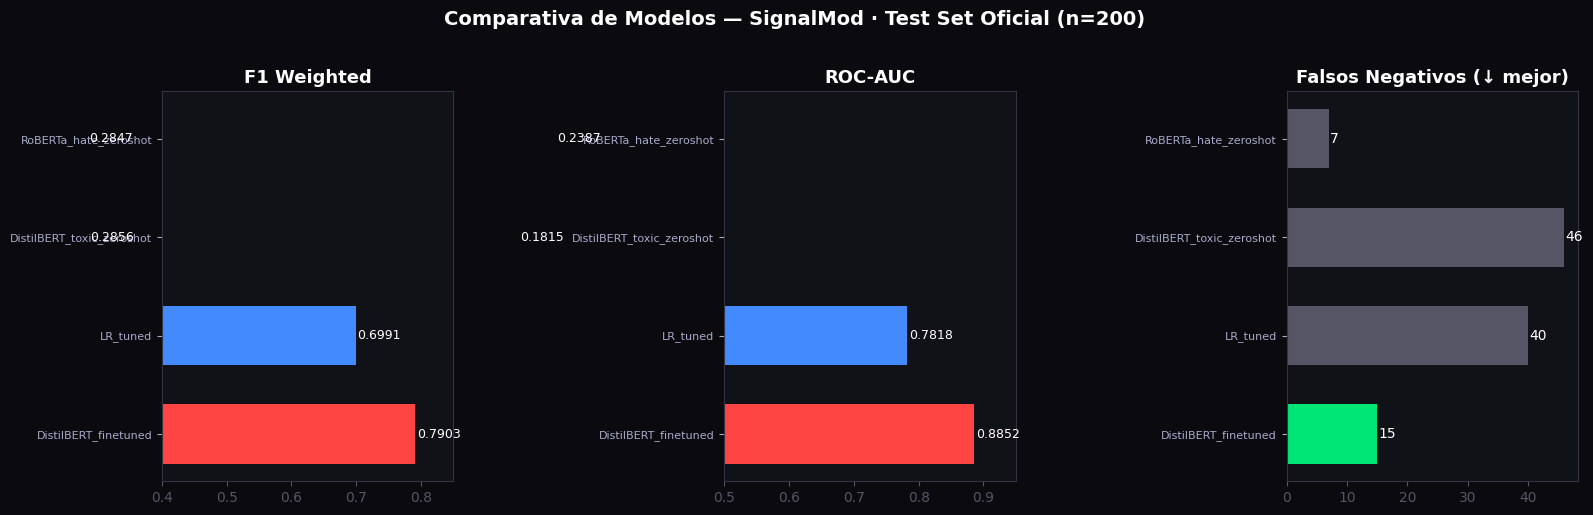

💾 Guardado: comparativa_modelos.png


In [ ]:
# ─── Plot 1: Barras comparativas F1 + ROC ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0a0a0f")
for ax in axes:
    ax.set_facecolor("#111118")

model_names = df_comparison["model"].tolist()
f1_vals     = df_comparison["f1_weighted"].tolist()
roc_vals    = [v if v else 0 for v in df_comparison["roc_auc"].tolist()]
fn_vals     = df_comparison["FN"].tolist()

colors_bars = [COLORS["toxic"] if i == 0 else COLORS["neutral"] 
               for i in range(len(model_names))]

# F1
bars = axes[0].barh(model_names, f1_vals, color=colors_bars, edgecolor="none", height=0.6)
axes[0].set_xlim(0.4, 0.85)
axes[0].set_title("F1 Weighted", color="white", fontsize=13, fontweight="bold")
axes[0].tick_params(colors="white")
for bar, val in zip(bars, f1_vals):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", color="white", fontsize=9)

# ROC-AUC
bars2 = axes[1].barh(model_names, roc_vals, color=colors_bars, edgecolor="none", height=0.6)
axes[1].set_xlim(0.5, 0.95)
axes[1].set_title("ROC-AUC", color="white", fontsize=13, fontweight="bold")
axes[1].tick_params(colors="white")
for bar, val in zip(bars2, roc_vals):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", color="white", fontsize=9)

# FN (menor = mejor)
bars3 = axes[2].barh(model_names, fn_vals,
                     color=[COLORS["safe"] if i == 0 else "#555566" for i in range(len(model_names))],
                     edgecolor="none", height=0.6)
axes[2].set_title("Falsos Negativos (↓ mejor)", color="white", fontsize=13, fontweight="bold")
axes[2].tick_params(colors="white")
for bar, val in zip(bars3, fn_vals):
    axes[2].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va="center", color="white", fontsize=10)

for ax in axes:
    ax.spines[:].set_color("#333344")
    ax.tick_params(axis="y", labelsize=8, colors="#aaaacc")
    ax.tick_params(axis="x", colors="#555566")

plt.suptitle("Comparativa de Modelos — SignalMod · Test Set Oficial (n=200)",
             color="white", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "comparativa_modelos.png", dpi=150, bbox_inches="tight",
            facecolor="#0a0a0f")
plt.show()
print("💾 Guardado: comparativa_modelos.png")


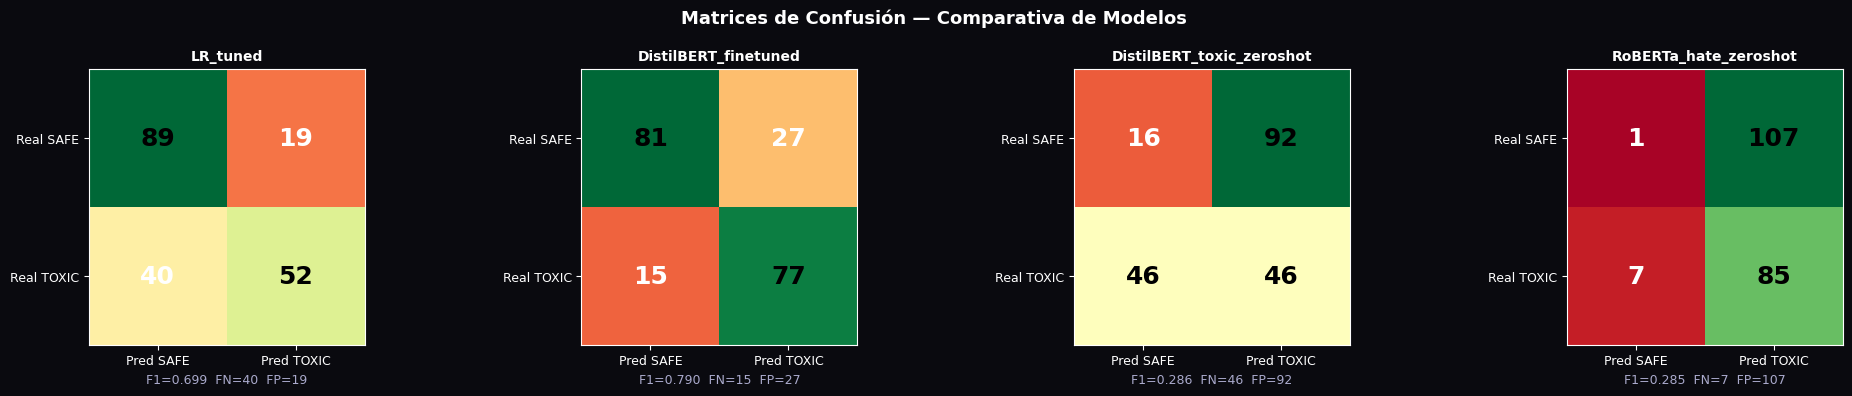

💾 Guardado: confusion_matrices.png


In [ ]:
# ─── Plot 2: Matrices de confusión lado a lado ───────────────────────────────
n_models = len(results_test)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
fig.patch.set_facecolor("#0a0a0f")
if n_models == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, results_test.items()):
    cm = confusion_matrix(y_test.values, res["preds"])
    
    im = ax.imshow(cm, cmap="RdYlGn", vmin=0, vmax=cm.max())
    ax.set_facecolor("#111118")
    
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i,j] < cm.max()/2 else "black"
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    fontsize=18, fontweight="bold", color=color)
    
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred SAFE", "Pred TOXIC"], color="white", fontsize=9)
    ax.set_yticklabels(["Real SAFE", "Real TOXIC"], color="white", fontsize=9)
    ax.set_title(model_name[:25], color="white", fontsize=10, fontweight="bold")
    ax.tick_params(colors="white")
    
    m = results_test[model_name]["metrics"]
    ax.set_xlabel(f"F1={m['f1_weighted']:.3f}  FN={m['FN']}  FP={m['FP']}",
                  color="#aaaacc", fontsize=9)

plt.suptitle("Matrices de Confusión — Comparativa de Modelos",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
plt.show()
print("💾 Guardado: confusion_matrices.png")


## 8. Análisis de errores: FP y FN del mejor modelo

¿Qué comentarios le están fallando al DistilBERT fine-tuneado?  
Esto es clave para entender los límites reales del modelo.


In [15]:
# ─── Análisis de errores del mejor modelo ────────────────────────────────────
best_model_name = df_comparison.iloc[0]["model"]
print(f"🏆 Analizando errores de: {best_model_name}")
print("=" * 70)

best_preds  = results_test[best_model_name]["preds"]
best_probas = results_test[best_model_name]["probas"]

# Índices de error
X_test_arr = X_test.values
y_test_arr = y_test.values

fn_mask = (best_preds == 0) & (y_test_arr == 1)  # Hate speech que se escapó
fp_mask = (best_preds == 1) & (y_test_arr == 0)  # Falsa alarma

fn_texts  = X_test_arr[fn_mask]
fn_probas = best_probas[fn_mask]
fp_texts  = X_test_arr[fp_mask]
fp_probas = best_probas[fp_mask]

print(f"\n🔴 FALSOS NEGATIVOS ({fn_mask.sum()}) — Hate speech NO detectado:")
print("  Estos son los más críticos. El modelo los clasificó como 'seguros'.")
print("-" * 70)
for i, (txt, prob) in enumerate(sorted(zip(fn_texts, fn_probas), key=lambda x: x[1])):
    print(f"  [{i+1}] P(toxic)={prob:.3f} | {txt[:120]}...")
    if i >= 9: print(f"  ... y {fn_mask.sum()-10} más"); break

print(f"\n🟡 FALSOS POSITIVOS ({fp_mask.sum()}) — Comentarios OK bloqueados:")
print("  El modelo los clasificó como 'tóxicos' pero son seguros.")
print("-" * 70)
for i, (txt, prob) in enumerate(sorted(zip(fp_texts, fp_probas), 
                                        key=lambda x: x[1], reverse=True)):
    print(f"  [{i+1}] P(toxic)={prob:.3f} | {txt[:120]}...")
    if i >= 9: print(f"  ... y {fp_mask.sum()-10} más"); break


🏆 Analizando errores de: DistilBERT_finetuned

🔴 FALSOS NEGATIVOS (15) — Hate speech NO detectado:
  Estos son los más críticos. El modelo los clasificó como 'seguros'.
----------------------------------------------------------------------
  [1] P(toxic)=0.071 | Ah, beautiful....
  [2] P(toxic)=0.125 | Seeing the comments on here just proves how backward this country is. ...
  [3] P(toxic)=0.209 | Hahahahaha.  This guy is Ed Bassmaster's character ALWAYS TESTE. Ed Bassmaster has a semi-retarded character who is cros...
  [4] P(toxic)=0.234 | I wish mr masri was dead,,...
  [5] P(toxic)=0.251 | Remember that time every other race rioted because someone of their race got shot by a white cop after attacking the off...
  [6] P(toxic)=0.294 | Bottom line: Michael Brown was a drug addict criminal, a violent criminal.
So why should anyone feel bad he got killed, ...
  [7] P(toxic)=0.302 | Was Stefan ever a victim of police discrimination? The game of white supremacy is to deny aNY involvement

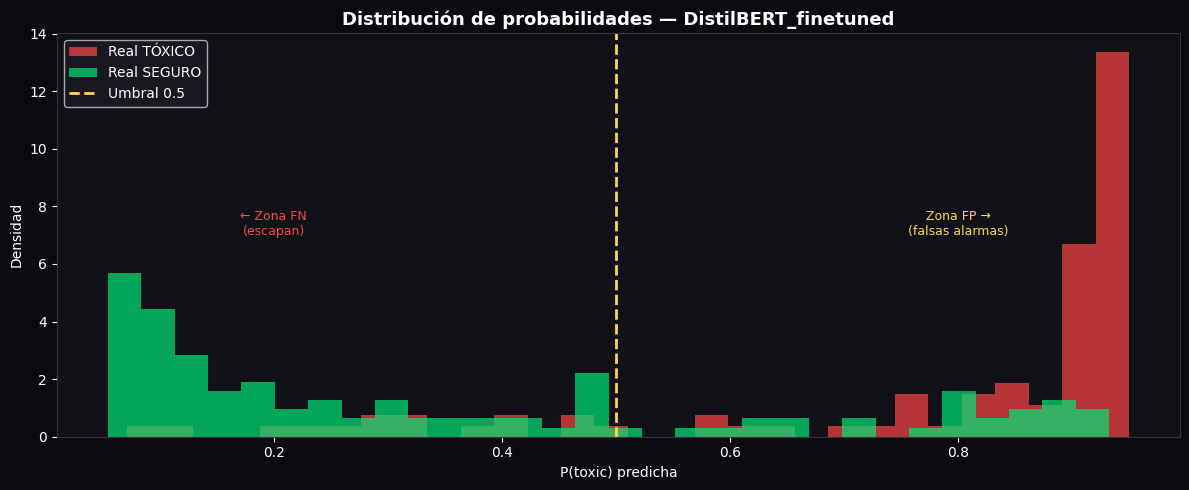

💾 Guardado: prob_distribution.png

Interpretación: la mejor separación posible son dos picos alejados del umbral 0.5


In [ ]:
# ─── Plot: Distribución de probabilidades por clase ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0a0a0f")
ax.set_facecolor("#111118")

toxic_probas   = best_probas[y_test_arr == 1]
nontoxic_probas= best_probas[y_test_arr == 0]

ax.hist(toxic_probas,    bins=30, alpha=0.7, color=COLORS["toxic"],  
        label="Real TÓXICO",   density=True)
ax.hist(nontoxic_probas, bins=30, alpha=0.7, color=COLORS["safe"],   
        label="Real SEGURO",   density=True)
ax.axvline(0.5, color=COLORS["warn"], linestyle="--", linewidth=2, label="Umbral 0.5")

ax.set_xlabel("P(toxic) predicha", color="white")
ax.set_ylabel("Densidad", color="white")
ax.set_title(f"Distribución de probabilidades — {best_model_name}", 
             color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a24", labelcolor="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333344")

# Anotaciones
ax.annotate("← Zona FN\n(escapan)", xy=(0.2, 0.5), xycoords=("data","axes fraction"),
            color=COLORS["toxic"], fontsize=9, ha="center")
ax.annotate("Zona FP →\n(falsas alarmas)", xy=(0.8, 0.5), xycoords=("data","axes fraction"),
            color=COLORS["warn"], fontsize=9, ha="center")

plt.tight_layout()
plt.savefig(REPORT_DIR / "prob_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
plt.show()
print("💾 Guardado: prob_distribution.png")
print("\nInterpretación: la mejor separación posible son dos picos alejados del umbral 0.5")


## 9. Optimización del umbral de decisión

El umbral por defecto es 0.5. Para YouTube, donde los FN son más dañinos que los FP,  
puede ser mejor bajar el umbral para detectar más hate speech a costa de más falsas alarmas.


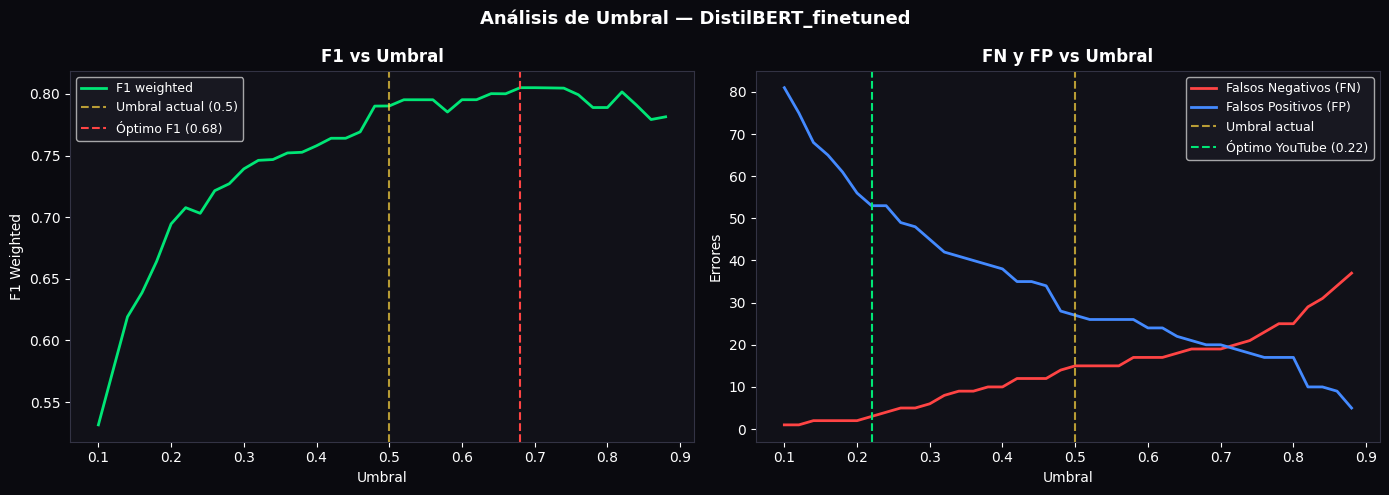


📊 ANÁLISIS DE UMBRAL — DistilBERT_finetuned
Configuración                     F1-w   FN   FP
--------------------------------------------------
Umbral 0.5 (actual)             0.7903   15   27
Umbral 0.68 (óptimo F1)         0.8051   19   20
Umbral 0.22 (óptimo YouTube)    0.7077    3   53
💾 Guardado: threshold_analysis.png


In [ ]:
# ─── Curva F1 vs Umbral ──────────────────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.02)
f1_weighted_list, fn_list, fp_list = [], [], []

best_probas_test = results_test[best_model_name]["probas"]

for t in thresholds:
    preds_t = (best_probas_test >= t).astype(int)
    f1_weighted_list.append(f1_score(y_test_arr, preds_t, average="weighted"))
    fn_list.append(int(((preds_t == 0) & (y_test_arr == 1)).sum()))
    fp_list.append(int(((preds_t == 1) & (y_test_arr == 0)).sum()))

# Umbral óptimo para F1
opt_idx = np.argmax(f1_weighted_list)
opt_threshold = thresholds[opt_idx]
opt_f1 = f1_weighted_list[opt_idx]

# Umbral óptimo para YouTube (minimiza FN con F1 > 0.70)
yt_mask = np.array(f1_weighted_list) > 0.70
yt_thresholds = thresholds[yt_mask]
yt_fn = np.array(fn_list)[yt_mask]
yt_best_idx = np.argmin(yt_fn)
yt_threshold = yt_thresholds[yt_best_idx] if len(yt_thresholds) > 0 else 0.4

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0a0a0f")
for ax in [ax1, ax2]:
    ax.set_facecolor("#111118")
    ax.spines[:].set_color("#333344")
    ax.tick_params(colors="white")

ax1.plot(thresholds, f1_weighted_list, color=COLORS["safe"], linewidth=2, label="F1 weighted")
ax1.axvline(0.5, color=COLORS["warn"], linestyle="--", alpha=0.7, label="Umbral actual (0.5)")
ax1.axvline(opt_threshold, color=COLORS["toxic"], linestyle="--", 
            label=f"Óptimo F1 ({opt_threshold:.2f})")
ax1.set_xlabel("Umbral", color="white"); ax1.set_ylabel("F1 Weighted", color="white")
ax1.set_title("F1 vs Umbral", color="white", fontweight="bold")
ax1.legend(facecolor="#1a1a24", labelcolor="white", fontsize=9)

ax2.plot(thresholds, fn_list, color=COLORS["toxic"],   linewidth=2, label="Falsos Negativos (FN)")
ax2.plot(thresholds, fp_list, color=COLORS["neutral"],  linewidth=2, label="Falsos Positivos (FP)")
ax2.axvline(0.5, color=COLORS["warn"], linestyle="--", alpha=0.7, label="Umbral actual")
ax2.axvline(yt_threshold, color=COLORS["safe"], linestyle="--",
            label=f"Óptimo YouTube ({yt_threshold:.2f})")
ax2.set_xlabel("Umbral", color="white"); ax2.set_ylabel("Errores", color="white")
ax2.set_title("FN y FP vs Umbral", color="white", fontweight="bold")
ax2.legend(facecolor="#1a1a24", labelcolor="white", fontsize=9)

plt.suptitle(f"Análisis de Umbral — {best_model_name}", 
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "threshold_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
plt.show()

preds_opt = (best_probas_test >= opt_threshold).astype(int)
preds_yt  = (best_probas_test >= yt_threshold).astype(int)

print(f"\n📊 ANÁLISIS DE UMBRAL — {best_model_name}")
print(f"{'Configuración':<30} {'F1-w':>7} {'FN':>4} {'FP':>4}")
print("-" * 50)
print(f"{'Umbral 0.5 (actual)':<30} "
      f"{f1_score(y_test_arr, best_preds, average='weighted'):>7.4f} "
      f"{fn_mask.sum():>4} {fp_mask.sum():>4}")
print(f"{'Umbral ' + str(round(opt_threshold,2)) + ' (óptimo F1)':<30} "
      f"{f1_score(y_test_arr, preds_opt, average='weighted'):>7.4f} "
      f"{int(((preds_opt==0)&(y_test_arr==1)).sum()):>4} "
      f"{int(((preds_opt==1)&(y_test_arr==0)).sum()):>4}")
print(f"{'Umbral ' + str(round(yt_threshold,2)) + ' (óptimo YouTube)':<30} "
      f"{f1_score(y_test_arr, preds_yt, average='weighted'):>7.4f} "
      f"{int(((preds_yt==0)&(y_test_arr==1)).sum()):>4} "
      f"{int(((preds_yt==1)&(y_test_arr==0)).sum()):>4}")
print("💾 Guardado: threshold_analysis.png")


## 10. Prueba en vivo: análisis de comentarios de un video de YouTube

> **Requisito:** YouTube Data API v3 Key (gratuita).  
> Cómo obtenerla: https://console.cloud.google.com → APIs & Services → YouTube Data API v3  
> La cuota gratuita es 10.000 unidades/día. Cada request de comentarios = ~1 unidad.  
>  
> Si no tienes la API key, esta sección se puede ejecutar con comentarios de ejemplo hardcodeados.


In [18]:
# ─── Configuración YouTube API ───────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()

# ⬇️  Pon tu API Key aquí (o usa variable de entorno)
YOUTUBE_API_KEY = os.environ.get("YOUTUBE_API_KEY", "")

# ⬇️  URL o ID del video que quieres analizar
# Ejemplos de videos con comentarios variados (temática policial/BLM como el dataset):
VIDEO_URL = "https://www.youtube.com/watch?v=04kJtp6pVXI"  # mismo video del dataset

MAX_COMMENTS = 50  # máx comentarios a analizar (100 = 1 unidad de cuota)

# ─── Extrae el video ID de la URL ─────────────────────────────────────────────
import re as _re
def extract_video_id(url):
    patterns = [
        r"youtube\.com/watch\?v=([^&]+)",
        r"youtu\.be/([^?]+)",
        r"youtube\.com/embed/([^?]+)",
    ]
    for pattern in patterns:
        m = _re.search(pattern, url)
        if m:
            return m.group(1)
    return url  # asume que ya es un ID

VIDEO_ID = extract_video_id(VIDEO_URL)
print(f"🎬 Video ID: {VIDEO_ID}")
print(f"🔑 API Key configurada: {'✅ SÍ' if YOUTUBE_API_KEY != 'TU_API_KEY_AQUI' else '❌ NO — edita YOUTUBE_API_KEY'}")


🎬 Video ID: 04kJtp6pVXI
🔑 API Key configurada: ✅ SÍ


In [19]:
# ─── Función para obtener comentarios ────────────────────────────────────────
def get_youtube_comments(video_id, api_key, max_results=100):
    """
    Obtiene comentarios de un video de YouTube usando la API v3.
    Devuelve lista de dicts con 'text', 'author', 'likes', 'published_at'.
    """
    try:
        from googleapiclient.discovery import build
    except ImportError:
        raise ImportError("Ejecuta: pip install google-api-python-client")
    
    youtube  = build("youtube", "v3", developerKey=api_key)
    comments = []
    next_page_token = None
    
    while len(comments) < max_results:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=min(100, max_results - len(comments)),
            pageToken=next_page_token,
            textFormat="plainText",
            order="relevance",  # 'time' para cronológico
        )
        response = request.execute()
        
        for item in response.get("items", []):
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "text"        : snippet["textDisplay"],
                "author"      : snippet["authorDisplayName"],
                "likes"       : snippet["likeCount"],
                "published_at": snippet["publishedAt"],
            })
        
        next_page_token = response.get("nextPageToken")
        if not next_page_token:
            break
    
    return comments[:max_results]


# ─── Fallback: comentarios de ejemplo si no hay API key ──────────────────────
FALLBACK_COMMENTS = [
    {"text": "This video is an important reminder of systemic issues we face",   
     "author": "User1", "likes": 45, "published_at": "2024-01-01"},
    {"text": "These black thugs deserve what they get, disgusting animals",       
     "author": "User2", "likes": 2,  "published_at": "2024-01-01"},
    {"text": "Police brutality is real and must be addressed by policy change",   
     "author": "User3", "likes": 89, "published_at": "2024-01-01"},
    {"text": "I hate all these protesters, they should be arrested",              
     "author": "User4", "likes": 1,  "published_at": "2024-01-01"},
    {"text": "We need more dialogue and less violence from all sides",            
     "author": "User5", "likes": 67, "published_at": "2024-01-01"},
    {"text": "Kill all these f***ing cops they are criminals",                    
     "author": "User6", "likes": 0,  "published_at": "2024-01-01"},
    {"text": "Peaceful protest is the foundation of democracy",                  
     "author": "User7", "likes": 123,"published_at": "2024-01-01"},
    {"text": "These immigrants ruining everything, send them all back home",      
     "author": "User8", "likes": 3,  "published_at": "2024-01-01"},
    {"text": "Very informative video, thank you for sharing",                    
     "author": "User9", "likes": 34, "published_at": "2024-01-01"},
    {"text": "You are all stupid idiots who don't understand reality",           
     "author": "User10","likes": 1,  "published_at": "2024-01-01"},
]

# ─── Obtener comentarios ──────────────────────────────────────────────────────
if YOUTUBE_API_KEY != "TU_API_KEY_AQUI":
    print(f"⏳ Obteniendo {MAX_COMMENTS} comentarios del video {VIDEO_ID}...")
    try:
        yt_comments = get_youtube_comments(VIDEO_ID, YOUTUBE_API_KEY, MAX_COMMENTS)
        print(f"✅ Obtenidos {len(yt_comments)} comentarios reales")
        using_real = True
    except Exception as e:
        print(f"❌ Error API: {e}")
        print("⚠️  Usando comentarios de ejemplo (fallback)")
        yt_comments = FALLBACK_COMMENTS
        using_real = False
else:
    print("⚠️  Sin API key — usando 10 comentarios de ejemplo hardcodeados")
    print("   Para usar comentarios reales: YOUTUBE_API_KEY = 'tu_key_aqui'")
    yt_comments = FALLBACK_COMMENTS
    using_real = False

print(f"\n📋 Total comentarios a analizar: {len(yt_comments)}")


⏳ Obteniendo 50 comentarios del video 04kJtp6pVXI...
✅ Obtenidos 50 comentarios reales

📋 Total comentarios a analizar: 50


In [20]:
# ─── Análisis con el mejor modelo ────────────────────────────────────────────
yt_texts = [c["text"] for c in yt_comments]

print(f"⏳ Analizando {len(yt_texts)} comentarios con {best_model_name}...")
t0 = time.time()

best_model_obj = models_loaded[best_model_name]
if best_model_name == "LR_tuned":
    yt_preds, yt_probas = predict_lr(yt_texts, best_model_obj)
else:
    yt_preds, yt_probas = predict_hf(yt_texts, best_model_obj)

elapsed = time.time() - t0
print(f"✅ Análisis completado en {elapsed:.1f}s")

# Enriquecer resultados
for i, comment in enumerate(yt_comments):
    comment["is_toxic"]    = bool(yt_preds[i])
    comment["toxic_prob"]  = float(yt_probas[i])
    comment["risk_level"]  = ("🔴 ALTO"   if yt_probas[i] > 0.75 else
                              "🟡 MEDIO"  if yt_probas[i] > 0.5  else
                              "🟢 BAJO")

n_toxic = sum(yt_preds)
print(f"\n📊 RESULTADOS DEL VIDEO:")
print(f"   Total comentarios  : {len(yt_comments)}")
print(f"   Tóxicos detectados : {n_toxic} ({n_toxic/len(yt_comments):.1%})")
print(f"   Seguros            : {len(yt_comments)-n_toxic} ({(len(yt_comments)-n_toxic)/len(yt_comments):.1%})")
print(f"   Velocidad          : {len(yt_comments)/elapsed:.1f} comentarios/segundo")


⏳ Analizando 50 comentarios con DistilBERT_finetuned...
✅ Análisis completado en 0.9s

📊 RESULTADOS DEL VIDEO:
   Total comentarios  : 50
   Tóxicos detectados : 16 (32.0%)
   Seguros            : 34 (68.0%)
   Velocidad          : 54.4 comentarios/segundo


In [21]:
# ─── Tabla de comentarios analizados ─────────────────────────────────────────
print("\n📋 COMENTARIOS POR NIVEL DE RIESGO:")
print("=" * 90)

# Ordenar por probabilidad de toxicidad (mayor primero)
sorted_comments = sorted(yt_comments, key=lambda x: x["toxic_prob"], reverse=True)

print(f"\n🔴 COMENTARIOS DE ALTO RIESGO (P > 0.75):")
print("-" * 90)
high_risk = [c for c in sorted_comments if c["toxic_prob"] > 0.75]
if high_risk:
    for c in high_risk[:10]:
        print(f"  P={c['toxic_prob']:.3f} | {c['author'][:15]:<15} | {c['text'][:80]}...")
else:
    print("  Ninguno detectado")

print(f"\n🟡 COMENTARIOS DE RIESGO MEDIO (0.5 < P ≤ 0.75):")
print("-" * 90)
med_risk = [c for c in sorted_comments if 0.5 < c["toxic_prob"] <= 0.75]
for c in med_risk[:5]:
    print(f"  P={c['toxic_prob']:.3f} | {c['author'][:15]:<15} | {c['text'][:80]}...")
if not med_risk:
    print("  Ninguno detectado")

print(f"\n🟢 COMENTARIOS SEGUROS (muestra):")
print("-" * 90)
safe = [c for c in sorted_comments if c["toxic_prob"] <= 0.5]
for c in safe[:5]:
    print(f"  P={c['toxic_prob']:.3f} | {c['author'][:15]:<15} | {c['text'][:80]}...")



📋 COMENTARIOS POR NIVEL DE RIESGO:

🔴 COMENTARIOS DE ALTO RIESGO (P > 0.75):
------------------------------------------------------------------------------------------
  P=0.929 | @ladylordess    | Dogs get "mad", intelligent people take effective action. 
Time to call in the s...
  P=0.905 | @MicrosoftCPU3  | There's down right stupid people that care more about yelling than understanding...
  P=0.873 | @Amazonrainfore | CNN interview gets testy over Ferguson protests? More like Cnn interviewer gets ...
  P=0.865 | @thepokerking99 | The protester is insane and a fool, mad because he was arrested years prior....
  P=0.835 | @Hiker1792      | I was waiting for one of those comic book punches where Bassem punches to his ri...
  P=0.791 | @bennieharris73 | He hard boiled that 🥚...
  P=0.761 | @jimmynaughton3 | That's gonna be my new catch-phrase. "Shoot to apprehend!"...

🟡 COMENTARIOS DE RIESGO MEDIO (0.5 < P ≤ 0.75):
---------------------------------------------------------------------

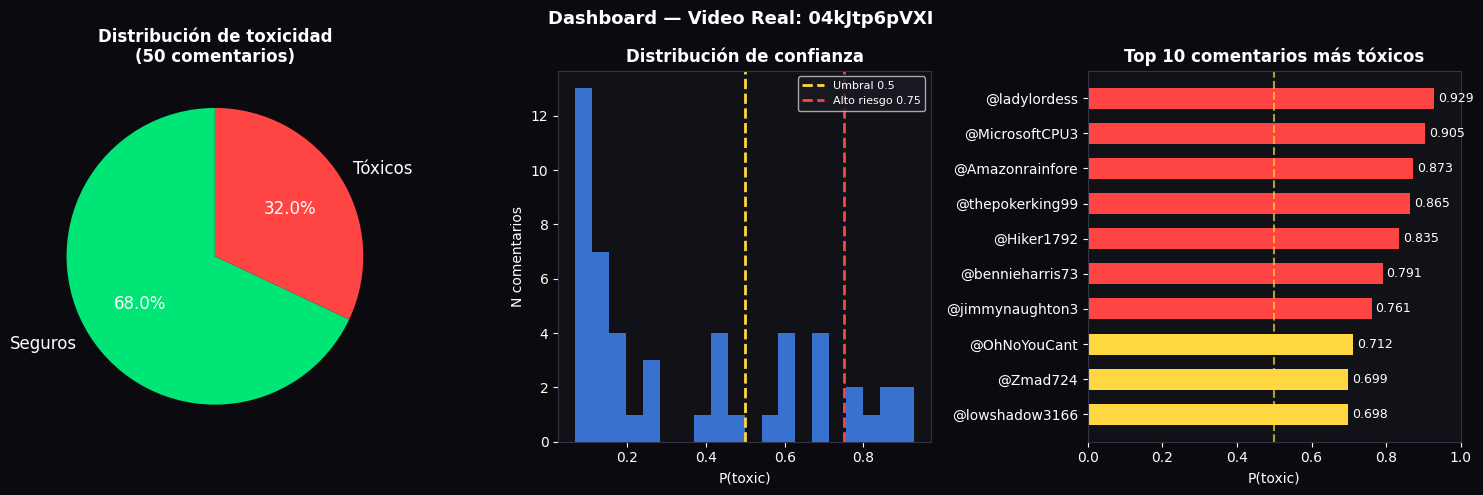

💾 Guardado: youtube_dashboard.png


In [ ]:
# ─── Dashboard visual del video ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#0a0a0f")
for ax in axes:
    ax.set_facecolor("#111118")

# Pie chart toxicidad
n_safe    = len(yt_comments) - n_toxic
axes[0].pie([n_safe, n_toxic],
            labels=["Seguros", "Tóxicos"],
            colors=[COLORS["safe"], COLORS["toxic"]],
            autopct="%1.1f%%", startangle=90,
            textprops={"color": "white", "fontsize": 12})
axes[0].set_title(f"Distribución de toxicidad\n({len(yt_comments)} comentarios)",
                  color="white", fontweight="bold")

# Histograma probabilidades
axes[1].hist(yt_probas, bins=20, color=COLORS["neutral"], edgecolor="none", alpha=0.8)
axes[1].axvline(0.5, color=COLORS["warn"], linestyle="--", linewidth=2, label="Umbral 0.5")
axes[1].axvline(0.75, color=COLORS["toxic"], linestyle="--", linewidth=2, label="Alto riesgo 0.75")
axes[1].set_xlabel("P(toxic)", color="white")
axes[1].set_ylabel("N comentarios", color="white")
axes[1].set_title("Distribución de confianza", color="white", fontweight="bold")
axes[1].legend(facecolor="#1a1a24", labelcolor="white", fontsize=8)
axes[1].tick_params(colors="white")

# Top 10 más tóxicos
top10 = sorted(yt_comments, key=lambda x: x["toxic_prob"], reverse=True)[:10]
top_texts  = [c["author"][:15] for c in top10]
top_probas = [c["toxic_prob"] for c in top10]
bar_colors = [COLORS["toxic"] if p > 0.75 else COLORS["warn"] for p in top_probas]
bars = axes[2].barh(top_texts[::-1], top_probas[::-1], color=bar_colors[::-1], height=0.6)
axes[2].set_xlim(0, 1)
axes[2].axvline(0.5, color=COLORS["warn"], linestyle="--", alpha=0.7)
axes[2].set_xlabel("P(toxic)", color="white")
axes[2].set_title("Top 10 comentarios más tóxicos", color="white", fontweight="bold")
axes[2].tick_params(colors="white")
for bar, val in zip(bars, top_probas[::-1]):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", color="white", fontsize=9)

for ax in axes[1:]:
    ax.spines[:].set_color("#333344")

title = f"Dashboard — {'Video Real: ' + VIDEO_ID if using_real else 'Comentarios de ejemplo'}"
plt.suptitle(title, color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORT_DIR / "youtube_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
plt.show()
print("💾 Guardado: youtube_dashboard.png")


## 11. Resumen ejecutivo — Tabla final reproducible

In [29]:
# ─── Tabla final exportable ──────────────────────────────────────────────────
print("\n" + "🏆"*35)
print("\n  RESUMEN EJECUTIVO — AUDITORÍA SIGNALMOD")
print("  Fecha:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"))
print("  Test set: n=200 | random_state=42 | stratified split 80/20")
print()

df_final = pd.DataFrame([v["metrics"] for v in results_test.values()])
df_final = df_final.sort_values("f1_weighted", ascending=False).reset_index(drop=True)

cols_show = ["model","accuracy","f1_weighted","f1_toxic","roc_auc","precision","recall","FP","FN"]
df_show = df_final[cols_show].copy()
df_show.columns = ["Modelo","Accuracy","F1-w","F1-toxic","ROC-AUC","Precision","Recall","FP","FN"]

# Formatear
for col in ["Accuracy","F1-w","F1-toxic","ROC-AUC","Precision","Recall"]:
    df_show[col] = df_show[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

print(df_show.to_string(index=True))

# Guardar CSV
df_final.to_csv(REPORT_DIR / "audit_results.csv", index=False)
print(f"\n💾 Resultados guardados en: {REPORT_DIR}/audit_results.csv")
print()

# Conclusión
winner = df_final.iloc[0]
print(f"  ✅ MEJOR MODELO : {winner['model']}")
print(f"     F1 Weighted  : {winner['f1_weighted']:.4f}")
print(f"     ROC-AUC      : {winner.get('roc_auc', 'N/A')}")
print(f"     FN           : {int(winner['FN'])} (hate speech que escapa)")
print(f"     FP           : {int(winner['FP'])} (falsas alarmas)")
print(f"     Recall       : {winner['recall']:.4f} → detecta el {winner['recall']:.1%} del hate speech real")
print()
print("  📌 Archivos generados en este directorio:")
print("     comparativa_modelos.png  — barras comparativas F1/ROC/FN")
print("     confusion_matrices.png   — matrices de confusión de todos los modelos")
print("     prob_distribution.png    — distribución de probabilidades")
print("     threshold_analysis.png   — análisis de umbral óptimo")
print("     youtube_dashboard.png    — análisis del video en vivo")
print("     audit_results.csv        — tabla exportable con todas las métricas")
print()



🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

  RESUMEN EJECUTIVO — AUDITORÍA SIGNALMOD
  Fecha: 2026-05-25 11:04
  Test set: n=200 | random_state=42 | stratified split 80/20

                      Modelo Accuracy    F1-w F1-toxic ROC-AUC Precision  Recall   FP  FN
0       DistilBERT_finetuned   0.7900  0.7903   0.7857  0.8852    0.7404  0.8370   27  15
1                   LR_tuned   0.7050  0.6991   0.6380  0.7818    0.7324  0.5652   19  40
2  DistilBERT_toxic_zeroshot   0.3100  0.2856   0.4000  0.1815    0.3333  0.5000   92  46
3      RoBERTa_hate_zeroshot   0.4300  0.2847   0.5986  0.2387    0.4427  0.9239  107   7

💾 Resultados guardados en: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/reports/v2/audit/audit_results.csv

  ✅ MEJOR MODELO : DistilBERT_finetuned
     F1 Weighted  : 0.7903
     ROC-AUC      : 0.8851650563607085
     FN           : 15 (hate speech que escapa)
     FP           : 27 (falsas alarmas)
     Recall       : 0.8370 → detecta el 83.7% del ha